# 03 — размер позиции и число одновременных (резерв 10%)

Вопрос (от пользователя): сейчас портфель = **50 позиций × 2% эквити** (= 100% капитала в рынке, резерва нет). Хотим **крупнее каждую позицию, но меньше одновременных**, и при этом **всегда держать 10% капитала нетронутым** (максимум 90% задействовано).

## Что значит «резерв 10%» механически
Новая позиция открывается **только если** `задействовано + новая_позиция ≤ 90% эквити`. То есть 10% эквити всегда лежит кэшем. Размер каждой позиции `p` и максимум одновременных `n` связаны: при полной загрузке `n·p = 90%`. Поэтому варианты ниже все дают 90% максимум, но по-разному дробят: много мелких ↔ мало крупных.

Поток сделок — тот же честный combined (`01_faithful_combined`): vol-gate +5%/15m & vol>3× для pump, классификатор (pred>0), стоп 20%, breadth-лимит, чистые комиссии. Кэширован в `_out/comb_trades.parquet`.

**Главный дисклеймер (читать до таблицы):** колонка `final$` при концентрации взлетает (компаундинг 2%-реинвеста). Это **потолок-фантазия**, а не прогноз: в `02_realistic_capacity` доказана стена ёмкости (медианная монета ~$2.7k/мин). Уже на ~$50k позиции бьются о ликвидность; $4.6M/$1.1B нарушают ёмкость на порядки. **Решают Sharpe и maxDD** — они компаунд-инвариантны и описывают форму риска, которую мы реально выбираем сплитом.

In [1]:
import sys; sys.path.insert(0,".")
from _lab import *
import numpy as np, pandas as pd, heapq

both = pd.read_parquet("_out/comb_trades.parquet")
START = 1000.
print(f"combined stream: {len(both)} trades, {both.entry.min()} .. {both.entry.max()}")

def daily_curve(eq_t, eq_v):
    s = pd.Series(eq_v, index=pd.to_datetime(eq_t)).sort_index()
    s = s[~s.index.duplicated(keep="last")]
    return s.resample("1D").last().ffill()

def book2(trades, n_concurrent, per_pos, reserve, start=START):
    """Reinvest book. notional = per_pos * equity.
    Open only if: free slot AND deployed+notional <= (1-reserve)*equity
    (=> reserve*equity is ALWAYS kept as untouched cash)."""
    t = trades.sort_values("entry")
    en = t.entry.values.astype("datetime64[ns]")
    ex = t.exit_ts.values.astype("datetime64[ns]")
    pnl = t.fpnl.values
    cash = start; dep = 0.; openh = []; eq_t = []; eq_v = []; taken = 0
    for i in range(len(pnl)):
        while openh and openh[0][0] <= en[i]:
            _, notional, pn = heapq.heappop(openh)
            cash += notional * (1 + pn); dep -= notional
            eq_t.append(pd.Timestamp(_)); eq_v.append(cash + dep)
        eq = cash + dep; notional = per_pos * eq
        if len(openh) < n_concurrent and dep + notional <= (1 - reserve) * eq and notional > 0:
            cash -= notional; dep += notional
            heapq.heappush(openh, (ex[i], notional, pnl[i])); taken += 1
    for _, notional, pn in sorted(openh):
        cash += notional * (1 + pn); dep -= notional
        eq_t.append(pd.Timestamp(_)); eq_v.append(cash + dep)
    return daily_curve(eq_t, eq_v), cash, taken

def metrics(eq):
    r = eq.pct_change().dropna()
    span = (eq.index[-1] - eq.index[0]).days / 365.25
    sh = r.mean() / r.std() * np.sqrt(365) if r.std() > 0 else np.nan
    peak = np.maximum.accumulate(eq.values); dd = (eq.values / peak - 1).min()
    return sh, dd, span

# all variants keep 10% reserve (n*p = 90%), except the current 50x2% reference (100%).
variants = [("50×2% (тек., без резерва)", 50, 0.02, 0.00),
            ("45×2%", 45, 0.02, 0.10), ("30×3%", 30, 0.03, 0.10),
            ("18×5%", 18, 0.05, 0.10), ("15×6%", 15, 0.06, 0.10),
            ("9×10%", 9, 0.10, 0.10), ("6×15%", 6, 0.15, 0.10),
            ("3×30%", 3, 0.30, 0.10)]
N = len(both); curves = {}; rows = []
for nm, n, p, res in variants:
    eq, fin, tk = book2(both, n, p, res); curves[nm] = eq
    sh, dd, span = metrics(eq)
    rows.append(dict(variant=nm, deployed=f"{n*p:.0%}", Sharpe=round(sh, 2),
                     maxDD=f"{dd:.1%}", pct_taken=f"{tk/N:.0%}",
                     CAGR=f"{(fin/START)**(1/span)-1:+.0%}", **{"final$ (ceiling*)": f"${fin:,.0f}"}))
tbl = pd.DataFrame(rows)
print("\n=== position-sizing sweep, reserve 10% (Sharpe & maxDD decide; final$ = capacity fantasy) ===")
print(tbl.to_string(index=False))

combined stream: 10783 trades, 2024-01-02 00:01:00+00:00 .. 2026-04-30 16:30:00+00:00



=== position-sizing sweep, reserve 10% (Sharpe & maxDD decide; final$ = capacity fantasy) ===
                  variant deployed  Sharpe  maxDD pct_taken    CAGR final$ (ceiling*)
50×2% (тек., без резерва)     100%    5.03  -9.3%       92%   +185%           $11,400
                    45×2%      90%    4.84 -10.3%       91%   +182%           $11,168
                    30×3%      90%    5.05 -11.2%       88%   +339%           $31,212
                    18×5%      90%    5.48 -18.1%       83%   +782%          $157,552
                    15×6%      90%    5.82 -22.6%       81%  +1122%          $336,086
                    9×10%      90%    6.51 -26.1%       74%  +3669%        $4,610,594
                    6×15%      90%    6.29 -27.9%       65%  +8256%       $29,348,846
                    3×30%      90%    5.84 -43.0%       44% +40056%    $1,127,844,131


[saved] notebooks\pump_dump_combined\_out\comb_03_sizing.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_03_sizing.png')

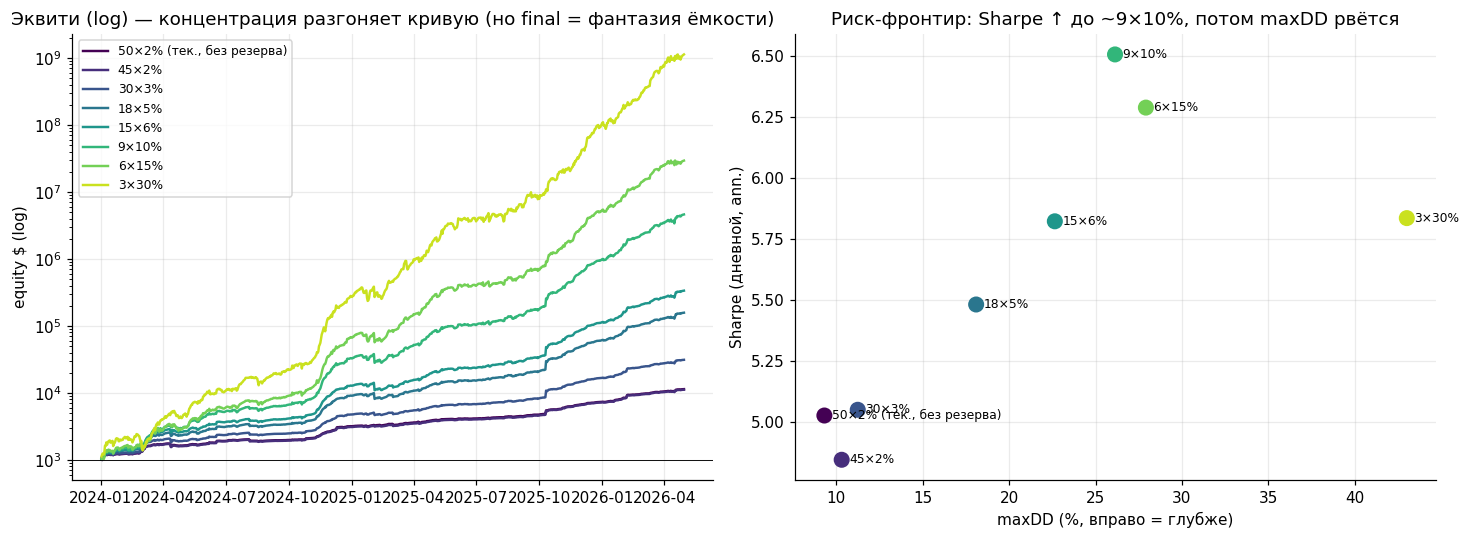

In [2]:
# Left: equity curves (log). Right: the risk frontier — Sharpe vs maxDD per split.
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(13.5, 5))
cmap = plt.cm.viridis(np.linspace(0, 0.92, len(variants)))
for (nm, *_), col in zip(variants, cmap):
    ax[0].plot(curves[nm].index, curves[nm].values, label=nm, color=col, lw=1.6)
ax[0].set_yscale("log"); ax[0].axhline(START, color="k", lw=.6)
ax[0].set_title("Эквити (log) — концентрация разгоняет кривую (но final = фантазия ёмкости)")
ax[0].set_ylabel("equity $ (log)"); ax[0].legend(fontsize=8, loc="upper left")
# frontier
shs = [metrics(curves[nm])[0] for nm, *_ in variants]
dds = [metrics(curves[nm])[1] * 100 for nm, *_ in variants]
ax[1].scatter([-d for d in dds], shs, c=cmap, s=90, zorder=3)
for (nm, *_), d, s in zip(variants, dds, shs):
    ax[1].annotate(nm, (-d, s), fontsize=8, xytext=(5, 0), textcoords="offset points", va="center")
ax[1].set_xlabel("maxDD (%, вправо = глубже)"); ax[1].set_ylabel("Sharpe (дневной, ann.)")
ax[1].set_title("Риск-фронтир: Sharpe ↑ до ~9×10%, потом maxDD рвётся")
show("comb_03_sizing")

## Вердикт

**Что реально меняется при «крупнее/меньше» (всё с резервом 10%):**
- **maxDD растёт монотонно**: 45×2% −10% → 18×5% −18% → 9×10% −26% → 3×30% −43%. Много мелких позиций = диверсификация = мелкая просадка; мало крупных = концентрация. Это честная цена концентрации.
- **Sharpe растёт до ~9×10% (≈6.5), потом падает.** Причина двойная: (1) крупнее ставка усиливает реальный положительный per-trade edge; (2) меньше слотов → больше сделок пропущено в кластерах (`%взято` 92%→44%), а пропускаются как раз коррелированные кластерные лузеры (защитный клиппинг). Дальше 9×10% размер позиции начинает доминировать и просадка съедает Sharpe.
- **`final$` игнорировать** как абсолют — это компаундинг + нарушение стены ёмкости (см. nb02). Форма (наклон вверх с концентрацией) реальна, уровень — нет.

**Рекомендация по риск-профилю (а не по фантазийному final):**
- Консервативно, ближе к текущему: **30×3%** — Sharpe ~5.0 как у текущего 50×2%, но с резервом 10% и лишь чуть глубже DD (−11% vs −9%). Минимальное изменение характера.
- Баланс «больше доходность, терпимый риск»: **18×5%** (Sharpe 5.5, DD −18%) или **15×6%** (Sharpe 5.8, DD −23%).
- **9×10%** — пик Sharpe (6.5), но DD −26% и сильная зависимость от ограниченного хвоста 2024–26; в настоящей альт-мании концентрация = катастрофа (флаг из nb09/nb02). Дальше (6×15%, 3×30%) — чистое ухудшение риск-профиля.

**Честные оговорки:** in-sample 2024–04.2026; рост Sharpe частично от защитного клиппинга ёмкости (entangled с размером); хвостовой риск short-vol при концентрации недомоделирован; стоп 20% на крупной позиции = крупный разовый удар по эквити (30% поз × −20% = −6% эквити за сделку).

## Через модель ёмкости (nb02): 18×5% против текущего 50×2%

Наивный свип выше игнорировал ликвидность. Подключаем модель из `02_realistic_capacity`:
лимит участия **10% от $-оборота за 30-мин окно** на сделку (`cap_notional = 0.10·liq·30`),
слиппедж = **10bp спред + 0.10·доля_участия** (рыночный импакт), MAX-слотов. Сравниваем
текущий **50×2% (резерв 0%)** с целевым **18×5% (резерв 10%)** по стартовому капиталу.
`liq` = медианный `close·volume` за сутки до входа (тот же расчёт, что в nb02).

In [3]:
FILL_MIN=30; PART_CAP=0.10; SPREAD=0.0010; IMPACT=0.10   # nb02 capacity model
def realbook2(df,n_concurrent,per_pos,reserve,start):
    df=df.sort_values('entry')
    en=df.entry.values.astype('datetime64[ns]'); ex=df.exit_ts.values.astype('datetime64[ns]')
    bpnl=df.fpnl.values; liq=df.liq.values; cap_notional=PART_CAP*liq*FILL_MIN
    cash=start;dep=0.;openh=[];eq_t=[];eq_v=[];taken=0;capped=0;slip_tot=0.
    for i in range(len(bpnl)):
        while openh and openh[0][0]<=en[i]:
            _,notional,pn=heapq.heappop(openh);cash+=notional*(1+pn);dep-=notional
            eq_t.append(pd.Timestamp(_));eq_v.append(cash+dep)
        eq=cash+dep; desired=per_pos*eq; room=max(0.0,(1-reserve)*eq-dep)
        notional=min(desired,cap_notional[i],room)        # size capped by liquidity AND reserve
        if notional<desired-1e-9: capped+=1
        if len(openh)<n_concurrent and notional>1:
            part=notional/(liq[i]*FILL_MIN); slip=SPREAD+IMPACT*part; slip_tot+=notional*slip
            cash-=notional;dep+=notional;heapq.heappush(openh,(ex[i],notional,bpnl[i]-slip));taken+=1
    for _,notional,pn in sorted(openh): cash+=notional*(1+pn);dep-=notional;eq_t.append(pd.Timestamp(_));eq_v.append(cash+dep)
    s=pd.Series(eq_v,index=pd.to_datetime(eq_t)).sort_index()
    s=s[~s.index.duplicated(keep='last')].resample('1D').last().ffill()
    return s,cash,taken,capped,slip_tot

def cap_stats(s,start):
    r=s.pct_change().dropna();span=(s.index[-1]-s.index[0]).days/365.25
    sh=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else np.nan
    peak=np.maximum.accumulate(s.values);dd=(s.values/peak-1).min()
    return (s.iloc[-1]/start)**(1/span)-1, sh, dd

configs=[('50\u00d72% (\u0442\u0435\u043a., \u0440\u0435\u0437.0%)',50,0.02,0.00),
         ('18\u00d75% (\u0440\u0435\u0437.10%)',18,0.05,0.10)]
starts=(1_000,10_000,50_000,200_000,1_000_000)
cap_curves={}; rows=[]
print(f'model: fill {FILL_MIN}m, part-cap {PART_CAP:.0%} $vol, slip {SPREAD*1e4:.0f}bp + {IMPACT:.2f}*part\n')
for nm,n,p,res in configs:
    for start in starts:
        s,fin,tk,cap,slip=realbook2(both,n,p,res,start); cg,sh,dd=cap_stats(s,start)
        cap_curves[(nm,start)]=(cg,sh,dd)
        rows.append(dict(config=nm,start=f'${start:,.0f}',final=f'${fin:,.0f}',
            CAGR=f'{cg:+.0%}',Sharpe=round(sh,2),maxDD=f'{dd:.1%}',
            capped=f'{cap/tk:.0%}',slip=f'${slip:,.0f}'))
print(pd.DataFrame(rows).to_string(index=False))

model: fill 30m, part-cap 10% $vol, slip 10bp + 0.10*part



              config      start      final  CAGR  Sharpe  maxDD capped       slip
50×2% (тек., рез.0%)     $1,000     $7,588 +139%    4.32  -9.5%    12%     $1,082
50×2% (тек., рез.0%)    $10,000    $48,853  +98%    3.50  -9.6%    20%    $11,992
50×2% (тек., рез.0%)    $50,000   $156,645  +63%    2.70  -9.4%    29%    $56,459
50×2% (тек., рез.0%)   $200,000   $411,183  +36%    2.03 -11.1%    45%   $197,286
50×2% (тек., рез.0%) $1,000,000 $1,307,323  +12%    1.02 -13.4%    69%   $747,555
     18×5% (рез.10%)     $1,000    $27,843 +318%    3.81 -19.9%    29%     $8,663
     18×5% (рез.10%)    $10,000    $92,423 +160%    2.80 -23.3%    41%    $46,862
     18×5% (рез.10%)    $50,000   $194,431  +79%    2.03 -22.8%    53%   $150,103
     18×5% (рез.10%)   $200,000   $376,802  +31%    1.17 -25.6%    67%   $415,563
     18×5% (рез.10%) $1,000,000 $1,005,903   +0%    0.10 -31.6%    89% $1,318,500


[saved] notebooks\pump_dump_combined\_out\comb_03_capacity.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_03_capacity.png')

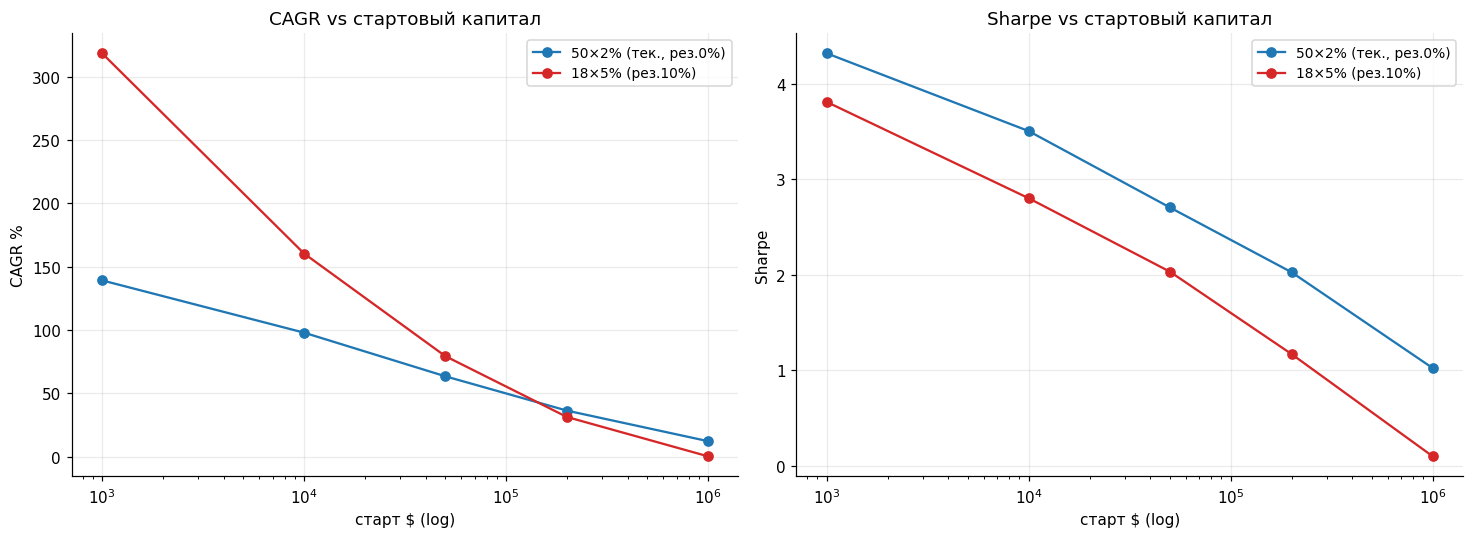

In [4]:
# CAGR & Sharpe vs start capital — does 18\u00d75% survive the liquidity wall?
fig,ax=plt.subplots(1,2,figsize=(13.5,5))
col={'50\u00d72% (\u0442\u0435\u043a., \u0440\u0435\u0437.0%)':'#1f77b4','18\u00d75% (\u0440\u0435\u0437.10%)':'#d62728'}
for nm,*_ in configs:
    cg=[cap_curves[(nm,s)][0]*100 for s in starts]; sh=[cap_curves[(nm,s)][1] for s in starts]
    ax[0].plot(starts,cg,'o-',label=nm,color=col[nm]); ax[1].plot(starts,sh,'o-',label=nm,color=col[nm])
for a,ti,yl in [(ax[0],'CAGR vs \u0441\u0442\u0430\u0440\u0442\u043e\u0432\u044b\u0439 \u043a\u0430\u043f\u0438\u0442\u0430\u043b','CAGR %'),(ax[1],'Sharpe vs \u0441\u0442\u0430\u0440\u0442\u043e\u0432\u044b\u0439 \u043a\u0430\u043f\u0438\u0442\u0430\u043b','Sharpe')]:
    a.set_xscale('log'); a.set_xlabel('\u0441\u0442\u0430\u0440\u0442 $ (log)'); a.set_ylabel(yl); a.set_title(ti); a.legend(fontsize=9)
show('comb_03_capacity')

## Вердикт по ёмкости (важный разворот)

Под реальной ликвидностью вывод **переворачивается** относительно наивного свипа:

- На **$1k** концентрация даёт больше сырого роста (CAGR +318% vs +139%, final $27.8k vs $7.6k), **НО ценой**: Sharpe **ниже** (3.81 < 4.32), просадка **вдвое глубже** (−20% vs −9.5%), capped 29% vs 12%, слиппедж ×8 ($8.7k vs $1.1k). Наивный «18×5% Sharpe 5.5» был артефактом мира без ликвидности — на реальной он 3.81, **хуже текущего 50×2%**.
- **Концентрация упирается в стену раньше.** Каждая позиция в 2.5× крупнее (5% vs 2%) → чаще пробивает лимит участия (10% $vol·30m) → больше capping и импакта. К $200k 18×5% уже отстаёт по CAGR (+31% vs +36%); на **$1M фактически мёртв** (+0.3% CAGR, Sharpe 0.10, 89% сделок урезано, $1.3M слиппеджа) против ещё живого 50×2% (+12%, Sharpe 1.02).

**Итог:** ёмкость наказывает именно крупный размер позиции. 18×5% оправдан **только** на очень малом счёте (≈$1–5k) и **только** если готов терпеть вдвое глубокую просадку (−20%) ради вдвое большего роста — Sharpe при этом всё равно ниже. Для устойчивости к масштабу и риск-профилю **много мелких (50×2% / 30×3%) объективно лучше**. Концентрация — это ставка «малый счёт + терпимость к DD», а не общий апгрейд.

**Оговорки:** параметры слиппеджа (10bp + 0.10·участие, 10% cap, 30m окно) — оценка из nb02, не калибровка по стакану; задержки/частичные филлы не моделированы; in-sample 2024–04.2026.

## DCA на итоговой (capacity) модели: $500 старт + $500/мес, без изъятий

Реальный режим накопления: каждый месяц довносим $500, ничего не забираем. Счёт растёт
медленно и **остаётся малым** → стена ёмкости почти не связывает. Сравниваем текущий
**50×2%** с **18×5% (резерв 10%)** под той же моделью слиппеджа/участия.

In [5]:
def realbook_dca(df,n_concurrent,per_pos,reserve,start,dca):
    df=df.sort_values('entry')
    en=df.entry.values.astype('datetime64[ns]'); ex=df.exit_ts.values.astype('datetime64[ns]')
    bpnl=df.fpnl.values; liq=df.liq.values; cap_notional=PART_CAP*liq*FILL_MIN
    cash=start;dep=0.;openh=[];eq_t=[];eq_v=[];taken=0;capped=0;slip_tot=0.;contrib=start
    months=list(pd.date_range(pd.Timestamp(en.min()).normalize().replace(day=1),pd.Timestamp(ex.max()),freq='MS')); mi=0
    for i in range(len(bpnl)):
        now=pd.Timestamp(en[i])
        while mi<len(months) and months[mi]<=now: cash+=dca;contrib+=dca;eq_t.append(months[mi]);eq_v.append(cash+dep);mi+=1
        while openh and openh[0][0]<=en[i]:
            _,notional,pn=heapq.heappop(openh);cash+=notional*(1+pn);dep-=notional;eq_t.append(pd.Timestamp(_));eq_v.append(cash+dep)
        eq=cash+dep; desired=per_pos*eq; room=max(0.0,(1-reserve)*eq-dep)
        notional=min(desired,cap_notional[i],room)
        if notional<desired-1e-9: capped+=1
        if len(openh)<n_concurrent and notional>1:
            part=notional/(liq[i]*FILL_MIN); slip=SPREAD+IMPACT*part; slip_tot+=notional*slip
            cash-=notional;dep+=notional;heapq.heappush(openh,(ex[i],notional,bpnl[i]-slip));taken+=1
    while mi<len(months): cash+=dca;contrib+=dca;eq_t.append(months[mi]);eq_v.append(cash+dep);mi+=1
    for _,notional,pn in sorted(openh): cash+=notional*(1+pn);dep-=notional;eq_t.append(pd.Timestamp(_));eq_v.append(cash+dep)
    s=pd.Series(eq_v,index=pd.to_datetime(eq_t)).sort_index();s=s[~s.index.duplicated(keep='last')].resample('1D').last().ffill()
    return s,cash,contrib,taken,capped,slip_tot

START_DCA=500.; DCA=500.
dca_curves={}; rows=[]
for nm,n,p,res in configs:
    s,fin,contrib,tk,cap,slip=realbook_dca(both,n,p,res,START_DCA,DCA); dca_curves[nm]=s
    r=s.pct_change().dropna(); peak=np.maximum.accumulate(s.values); dd=(s.values/peak-1).min()
    sh=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else float('nan')
    rows.append(dict(config=nm,contributed=f'${contrib:,.0f}',final=f'${fin:,.0f}',
        mult=f'{fin/contrib:.2f}x',maxDD=f'{dd:.1%}',Sharpe=round(sh,2),capped=f'{cap/tk:.0%}',slip=f'${slip:,.0f}'))
print(f'DCA: start ${START_DCA:.0f} + ${DCA:.0f}/month, no withdrawals (capacity model)\n')
print(pd.DataFrame(rows).to_string(index=False))

DCA: start $500 + $500/month, no withdrawals (capacity model)

              config contributed   final  mult  maxDD  Sharpe capped    slip
50×2% (тек., рез.0%)     $14,500 $38,475 2.65x  -9.5%    3.73    17%  $6,344
     18×5% (рез.10%)     $14,500 $70,661 4.87x -21.0%    3.78    37% $26,240


[saved] notebooks\pump_dump_combined\_out\comb_03_dca.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_03_dca.png')

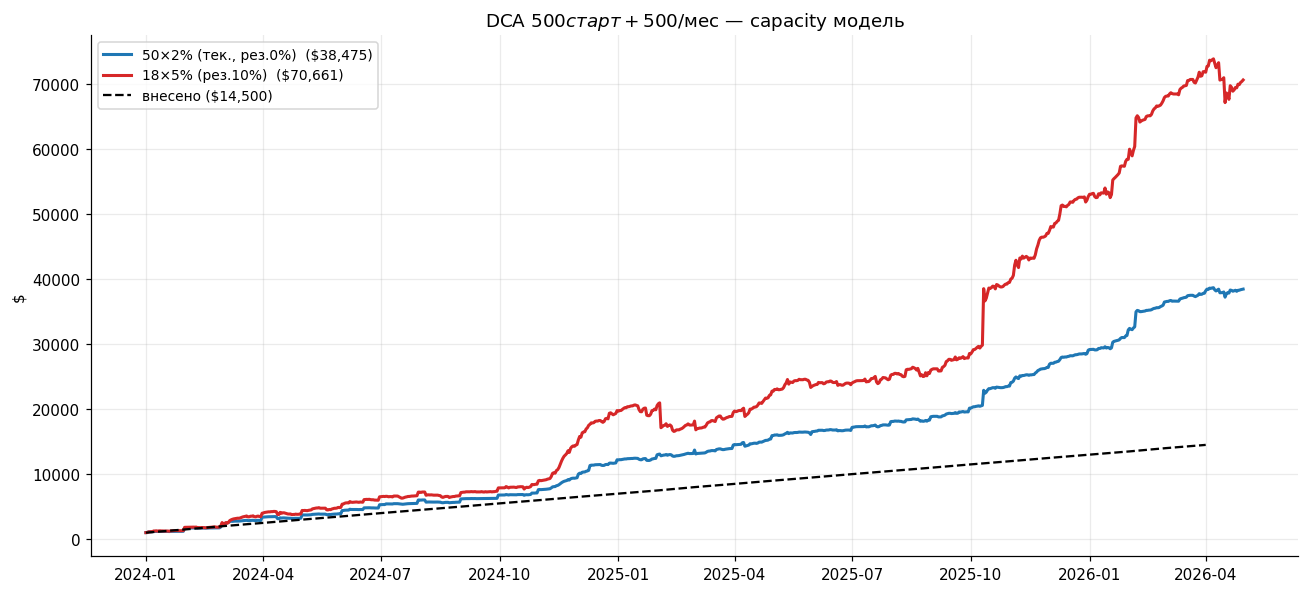

In [6]:
# DCA equity curves vs the contributions staircase
plt.figure(figsize=(12,5.5))
any_s=next(iter(dca_curves.values()))
months=pd.date_range(pd.Timestamp(both.entry.min()).normalize().replace(day=1),pd.Timestamp(both.exit_ts.max()),freq='MS')
contrib_line=pd.Series([START_DCA+DCA*(i+1) for i in range(len(months))],index=months)
col={'50\u00d72% (\u0442\u0435\u043a., \u0440\u0435\u0437.0%)':'#1f77b4','18\u00d75% (\u0440\u0435\u0437.10%)':'#d62728'}
for nm,s in dca_curves.items():
    plt.plot(s.index,s.values,lw=2,color=col[nm],label=f'{nm}  (${s.iloc[-1]:,.0f})')
plt.plot(contrib_line.index,contrib_line.values,'k--',label=f'\u0432\u043d\u0435\u0441\u0435\u043d\u043e (${contrib_line.iloc[-1]:,.0f})')
plt.title('DCA $500 \u0441\u0442\u0430\u0440\u0442 + $500/\u043c\u0435\u0441 \u2014 capacity \u043c\u043e\u0434\u0435\u043b\u044c'); plt.ylabel('$'); plt.legend(fontsize=9)
show('comb_03_dca')

## Вердикт по DCA (разворот №2)

При DCA $500+$500/мес вывод снова меняется относительно lump-sum:

- **18×5% даёт почти ×2 денег** ($70.7k vs $38.5k; 4.87× vs 2.65× на внесённые $14.5k) **при равном Sharpe** (3.78 ≈ 3.73). Причина: DCA держит счёт малым, поэтому стена ёмкости почти не связывает (та, что убивала 18×5% на крупном lump-sum), а регулярные взносы сглаживают кривую и подтягивают Sharpe концентрированной версии к уровню мелкой.
- **Цена прежняя и реальная: вдвое глубокая просадка** (−21% vs −9.5%) и ×4 слиппедж ($26k vs $6.3k, capped 37% vs 17%).

**Итог для режима накопления:** если копишь малыми регулярными взносами и психологически держишь −21% просадку — **18×5% объективно привлекательнее** (тот же Sharpe, ~вдвое итог). Если просадка −20% некомфортна — оставайся на 50×2% (−9.5%) или возьми промежуточный 30×3%. Концентрация выгодна именно в DCA-режиме малого счёта, и невыгодна на крупном lump-sum (стена ёмкости).

**Оговорки:** те же — параметры слиппеджа оценочные (не калибровка по стакану), задержки/частичные филлы не моделированы, in-sample 2024–04.2026, и −21% — это modelled MTM, реальная может быть глубже в настоящей альт-мании.

## Итог: 3 рабочих режима алгоритма

Считаем всю лесенку сплитов под **реальной DCA+capacity моделью** ($500 старт + $500/мес,
резерв 10%, слиппедж/участие как в nb02) и выбираем 3 пресета.

**Главное наблюдение — Sharpe почти плоский (~3.7–3.8) по всей лесенке.** Значит три режима
это НЕ три стратегии, а **одна ручка громкости**: концентрация линейно меняет и рост, и
просадку вместе, риск-скоррект. результат при этом не растёт. Это легитимная «ручка риска
под толерантность к просадке», но не изощрённость — и агрессивный режим хрупок именно там,
где модель слабее всего (short-vol хвост недомоделирован).

In [7]:
# full ladder under DCA+capacity; 3 presets highlighted
ladder=[('50\u00d72%',50,0.02,0.00),('45\u00d72%',45,0.02,0.10),('40\u00d72.25%',40,0.0225,0.10),
        ('30\u00d73%',30,0.03,0.10),('24\u00d73.75%',24,0.0375,0.10),('18\u00d75%',18,0.05,0.10),
        ('12\u00d77.5%',12,0.075,0.10),('9\u00d710%',9,0.10,0.10)]
PRESETS={'50\u00d72%':'\U0001f7e2 \u0411\u0435\u0437\u043e\u043f\u0430\u0441\u043d\u044b\u0439','30\u00d73%':'\U0001f7e1 \u0421\u0440\u0435\u0434\u043d\u0438\u0439','18\u00d75%':'\U0001f534 \u0410\u0433\u0440\u0435\u0441\u0441\u0438\u0432\u043d\u044b\u0439'}
STARTDCA, MDCA = 500., 500.
lad=[]
for nm,n,p,res in ladder:
    s,fin,contrib,tk,cap,slip=realbook_dca(both,n,p,res,STARTDCA,MDCA)
    r=s.pct_change().dropna(); peak=np.maximum.accumulate(s.values); dd=(s.values/peak-1).min()
    sh=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else float('nan')
    lad.append(dict(split=nm,final=fin,mult=fin/contrib,dd=dd,sh=sh,cap=cap/tk,slip=slip,
                    preset=PRESETS.get(nm,'')))
L=pd.DataFrame(lad)
show_tbl=L.assign(**{'final$':L.final.map('${:,.0f}'.format),'mult':L['mult'].map('{:.2f}x'.format),
    'maxDD':L.dd.map('{:.1%}'.format),'Sharpe':L.sh.round(2),'capped':L.cap.map('{:.0%}'.format),
    'slip$':L.slip.map('${:,.0f}'.format)})[['split','preset','final$','mult','maxDD','Sharpe','capped','slip$']]
print('=== ladder (DCA $500+$500/mo, capacity model); 3 presets marked ===')
print(show_tbl.to_string(index=False))

=== ladder (DCA $500+$500/mo, capacity model); 3 presets marked ===
   split        preset  final$  mult  maxDD  Sharpe capped   slip$
   50×2%  🟢 Безопасный $38,475 2.65x  -9.5%    3.73    17%  $6,344
   45×2%               $38,406 2.65x -10.2%    3.70    17%  $6,275
40×2.25%               $42,183 2.91x -12.4%    3.71    19%  $7,603
   30×3%     🟡 Средний $52,075 3.59x -11.5%    3.83    25% $12,359
24×3.75%               $59,860 4.13x -14.2%    3.83    30% $17,433
   18×5% 🔴 Агрессивный $70,661 4.87x -21.0%    3.78    37% $26,240
 12×7.5%               $84,786 5.85x -29.2%    3.74    49% $46,792
   9×10%               $89,083 6.14x -34.1%    3.46    60% $64,568


[saved] notebooks\pump_dump_combined\_out\comb_03_modes.png


C:\projects\researchlab\notebooks\pump_dump_combined\_lab.py:58: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\projects\researchlab\notebooks\pump_dump_combined\_lab.py:58: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\projects\researchlab\notebooks\pump_dump_combined\_lab.py:58: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\projects\researchlab\notebooks\pump_dump_combined\_lab.py:60: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.savefig(path, dpi=110, bbox_inches="tight")
C:\projects\researchlab\notebooks\pump_dump_combined\_lab.py:60: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.savefig(path, dpi=110, bbox_inches="tight")
C:\projects\researchlab\notebooks\pump_dump_combined\_lab.py:60: UserWarning: Glyph 128

WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_03_modes.png')

C:\projects\researchlab\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\projects\researchlab\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\projects\researchlab\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\projects\researchlab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\projects\researchlab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\projects\researchlab\.venv\L

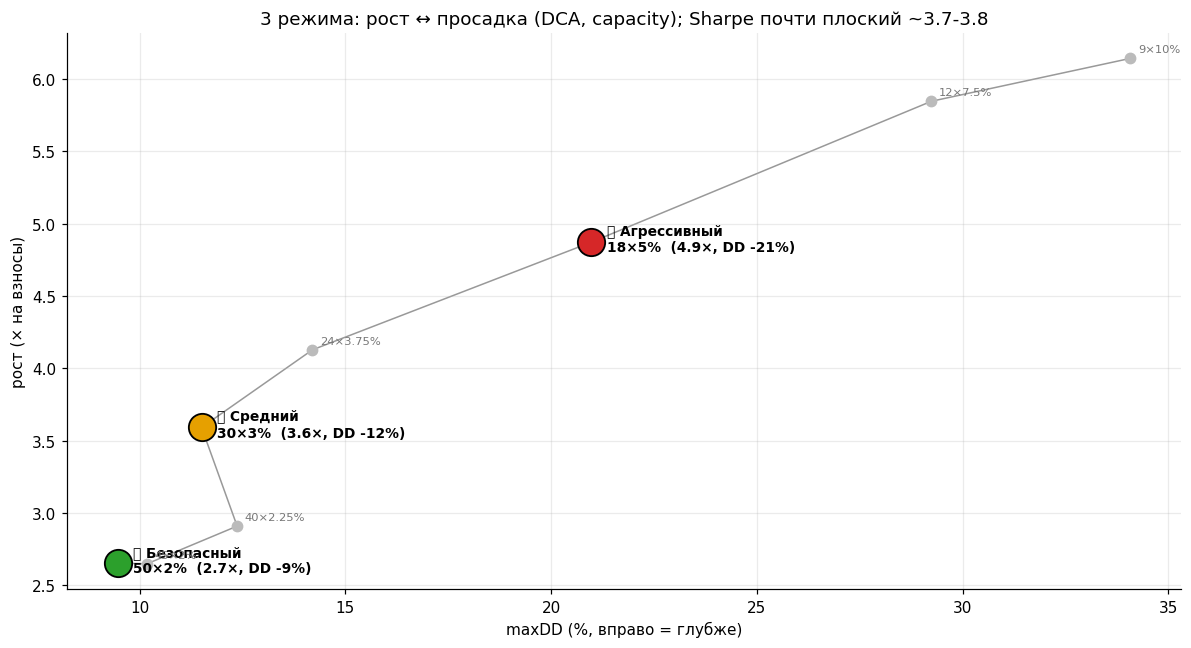

In [8]:
# growth vs drawdown frontier; the 3 presets called out
fig,axx=plt.subplots(figsize=(11,6))
axx.plot(-L.dd*100, L['mult'], '-', color='#999', lw=1, zorder=1)
axx.scatter(-L.dd*100, L['mult'], s=45, color='#bbb', zorder=2)
pcol={'\U0001f7e2 \u0411\u0435\u0437\u043e\u043f\u0430\u0441\u043d\u044b\u0439':'#2ca02c','\U0001f7e1 \u0421\u0440\u0435\u0434\u043d\u0438\u0439':'#e6a000','\U0001f534 \u0410\u0433\u0440\u0435\u0441\u0441\u0438\u0432\u043d\u044b\u0439':'#d62728'}
for _,row in L[L.preset!=''].iterrows():
    axx.scatter(-row.dd*100,row['mult'],s=320,color=pcol[row.preset],zorder=3,edgecolor='k',lw=1.2)
    axx.annotate(f"{row.preset}\n{row.split}  ({row['mult']:.1f}\u00d7, DD {row.dd:.0%})",
        (-row.dd*100,row['mult']), fontsize=9, xytext=(10,-6), textcoords='offset points', fontweight='bold')
for _,row in L[L.preset==''].iterrows():
    axx.annotate(row.split,(-row.dd*100,row['mult']),fontsize=7.5,color='#777',xytext=(5,4),textcoords='offset points')
axx.set_xlabel('maxDD (%, \u0432\u043f\u0440\u0430\u0432\u043e = \u0433\u043b\u0443\u0431\u0436\u0435)'); axx.set_ylabel('\u0440\u043e\u0441\u0442 (\u00d7 \u043d\u0430 \u0432\u0437\u043d\u043e\u0441\u044b)')
axx.set_title('3 \u0440\u0435\u0436\u0438\u043c\u0430: \u0440\u043e\u0441\u0442 \u2194 \u043f\u0440\u043e\u0441\u0430\u0434\u043a\u0430 (DCA, capacity); Sharpe \u043f\u043e\u0447\u0442\u0438 \u043f\u043b\u043e\u0441\u043a\u0438\u0439 ~3.7-3.8')
show('comb_03_modes')

## Вердикт: рекомендуемые режимы

| режим | параметры | maxDD | рост (DCA) | Sharpe | для кого |
|---|---|---|---|---|---|
| \U0001f7e2 **Безопасный** | **50\u00d72%, резерв 10%** | ~\u221210% | 2.65\u00d7 | 3.70 | дефолт; лучше всех терпит хвостовой риск |
| \U0001f7e1 **Средний** | **30\u00d73%, резерв 10%** | ~\u221212% | 3.59\u00d7 | 3.83 | лучший баланс: +35% к итогу, DD чуть глубже, Sharpe даже выше |
| \U0001f534 **Агрессивный** | **18\u00d75%, резерв 10%** | ~\u221221% | 4.87\u00d7 | 3.78 | только малый счёт + явная готовность к \u221220% |

**Почему именно эти три:**
- Безопасный = текущий 50\u00d72% (с резервом 10% \u2014 почти не меняет \u22129.5%\u2192\u221210%). Самый робастный к неучтённому short-vol хвосту.
- Средний = 30\u00d73% \u2014 скрытый дефолт: +35% к итогу над безопасным при просадке всего \u221212% и **самом высоком Sharpe лесенки** (3.83). Почти бесплатный апгрейд.
- Агрессивный = 18\u00d75% \u2014 разумный потолок. Дальше (12\u00d77.5%, 9\u00d710%) просадка рвётся к \u221229\u2026\u221234%, capped 49\u201360% (половина+ сделок бьётся о ликвидность), Sharpe падает \u2014 ускоряющаяся просадка за затухающую отдачу.

**Стоит ли так делать (честно):** да \u2014 как **ручка риска под толерантность к просадке**, с резервом 10% во всех режимах. НО: это одна стратегия на трёх уровнях «громкости», не три разных алгоритма (Sharpe плоский). Не продавать как изощрённость. Режим лучше **привязать к размеру счёта**, а не переключать на ходу (погоня за доходностью после удачного периода = слив). Агрессивный режим самый хрупкий именно к неучтённому риску \u2014 рекомендовать только осознанно.

**Оговорки:** всё in-sample 2024\u201304.2026; параметры слиппеджа оценочные; \u221221% \u2014 modelled MTM, в реальной альт-мании концентрация может дать глубже.